# Machine Learning Model Evaluation and Comparison

## Objective
Evaluate and compare multiple classification models, select appropriate evaluation metrics, and demonstrate overfitting/underfitting using the **Mall Customers** dataset.

**Target:** `High_Spender` = 1 when Spending Score ≥ 60, otherwise 0.

> Note: The original dataset is commonly used for customer segmentation, but this notebook converts it into a supervised **binary classification** problem so that it directly satisfies the internship task requirements for model evaluation, comparison, train-test split, and overfitting/underfitting analysis.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

RANDOM_STATE = 42
DATA_PATH = "Mall_Customers(1).csv"

df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 1. Data inspection and preparation

In [2]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))
print("\nSummary statistics:")
display(df.describe(include="all").T)

Shape: (200, 5)

Data types:


,dtype
CustomerID,int64
Genre,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64



Missing values:


,missing
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Genre,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


In [3]:
# Create a binary classification target.
# A spending score of 60 or above is treated as high spending.
df["High_Spender"] = (df["Spending Score (1-100)"] >= 60).astype(int)

features = ["Genre", "Age", "Annual Income (k$)"]
target = "High_Spender"

X = df[features]
y = df[target]

print("Target distribution:")
display(y.value_counts().rename({0:"Not High Spender", 1:"High Spender"}).to_frame("count"))
print("\nTarget proportions:")
display(y.value_counts(normalize=True).rename({0:"Not High Spender", 1:"High Spender"}).round(3).to_frame("proportion"))

Target distribution:


,count
High_Spender,
Not High Spender,135
High Spender,65



Target proportions:


,proportion
High_Spender,
Not High Spender,0.675
High Spender,0.325


## 2. Train-test split

A **stratified 80/20 train-test split** is used. Stratification keeps the class proportions similar in both sets and the test set remains unseen during model fitting.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training class distribution:", y_train.value_counts().to_dict())
print("Testing class distribution:", y_test.value_counts().to_dict())

Training samples: 160
Testing samples: 40
Training class distribution: {0: 108, 1: 52}
Testing class distribution: {0: 27, 1: 13}


## 3. Preprocessing pipeline

`Genre` is one-hot encoded and numeric features are standardized. Using a pipeline prevents preprocessing from leaking test-set information into training.

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), ["Genre"]),
        ("num", StandardScaler(), ["Age", "Annual Income (k$)"])
    ]
)

## 4. Models

Five classification algorithms are compared:

1. Logistic Regression — simple linear baseline.
2. Decision Tree — interpretable nonlinear rules.
3. Random Forest — ensemble of decision trees.
4. K-Nearest Neighbors — distance-based classifier.
5. Support Vector Machine (RBF) — nonlinear margin-based classifier.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=5, random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

## 5. Evaluation metrics

- **Accuracy:** overall proportion of correct predictions.
- **Precision:** among predicted high spenders, how many are actually high spenders.
- **Recall:** among actual high spenders, how many the model identifies.
- **F1-score:** harmonic mean of precision and recall.
- **ROC-AUC:** ranking/discrimination ability across classification thresholds.

Because the two classes are not perfectly balanced, **F1-score, precision, recall, and ROC-AUC** are more informative than accuracy alone.

In [7]:
results = []
predictions = {}
probabilities = {}
confusion_matrices = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    predictions[name] = pred
    probabilities[name] = prob
    confusion_matrices[name] = confusion_matrix(y_test, pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results).sort_values(
    by=["F1 Score", "ROC-AUC"], ascending=False
).reset_index(drop=True)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,K-Nearest Neighbors,0.775,0.6111,0.8462,0.7097,0.8561
1,Decision Tree,0.775,0.6111,0.8462,0.7097,0.8433
2,Random Forest,0.750,0.5882,0.7692,0.6667,0.8219
3,SVM,0.725,0.5714,0.6154,0.5926,0.8234
4,Logistic Regression,0.550,0.2727,0.2308,0.2500,0.6695


### Performance comparison table

In [8]:
comparison_table = results_df.copy()
comparison_table.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,K-Nearest Neighbors,0.775,0.6111,0.8462,0.7097,0.8561
1,Decision Tree,0.775,0.6111,0.8462,0.7097,0.8433
2,Random Forest,0.750,0.5882,0.7692,0.6667,0.8219
3,SVM,0.725,0.5714,0.6154,0.5926,0.8234
4,Logistic Regression,0.550,0.2727,0.2308,0.2500,0.6695


## 6. Confusion matrices and classification reports

In [9]:
for name in results_df["Model"]:
    print("=" * 70)
    print(name)
    print("Confusion matrix:")
    print(confusion_matrices[name])
    print("\nClassification report:")
    print(classification_report(
        y_test, predictions[name],
        target_names=["Not High Spender", "High Spender"],
        zero_division=0
    ))

K-Nearest Neighbors
Confusion matrix:
[[20  7]
 [ 2 11]]

Classification report:
                  precision    recall  f1-score   support

Not High Spender       0.91      0.74      0.82        27
    High Spender       0.61      0.85      0.71        13

        accuracy                           0.78        40
       macro avg       0.76      0.79      0.76        40
    weighted avg       0.81      0.78      0.78        40

Decision Tree
Confusion matrix:
[[20  7]
 [ 2 11]]

Classification report:
                  precision    recall  f1-score   support

Not High Spender       0.91      0.74      0.82        27
    High Spender       0.61      0.85      0.71        13

        accuracy                           0.78        40
       macro avg       0.76      0.79      0.76        40
    weighted avg       0.81      0.78      0.78        40

Random Forest
Confusion matrix:
[[20  7]
 [ 3 10]]

Classification report:
                  precision    recall  f1-score   support

Not High

## 7. Visual comparison of models

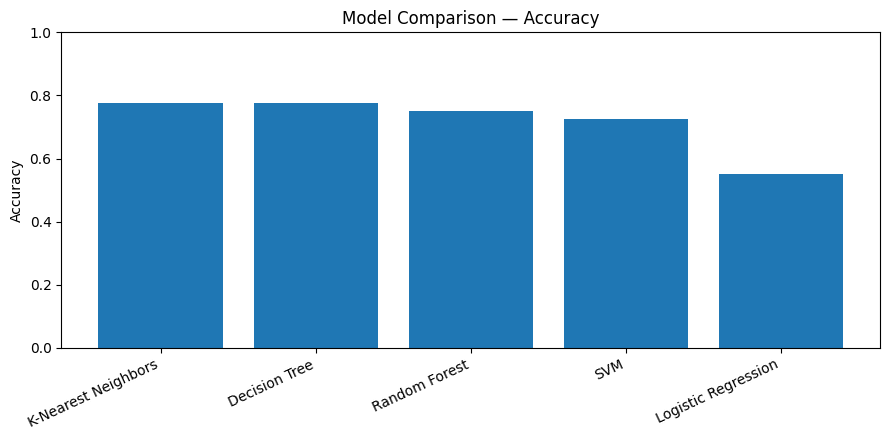

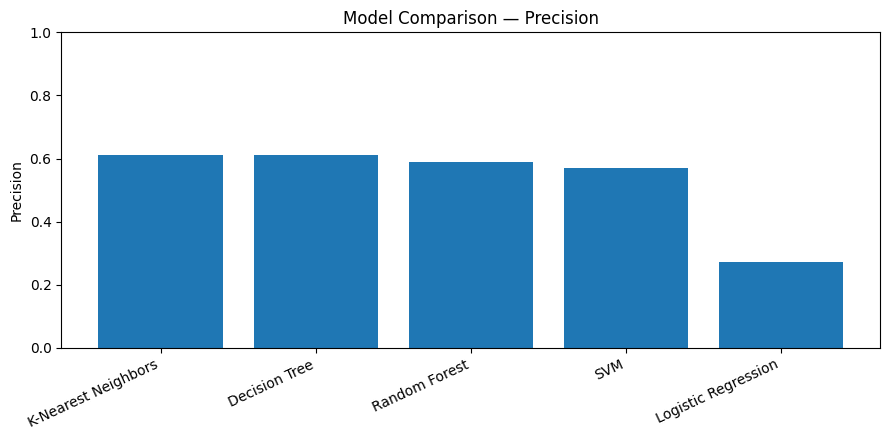

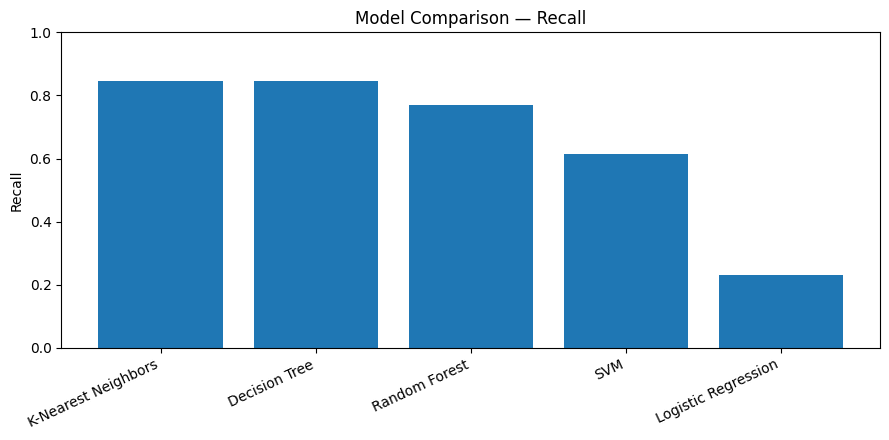

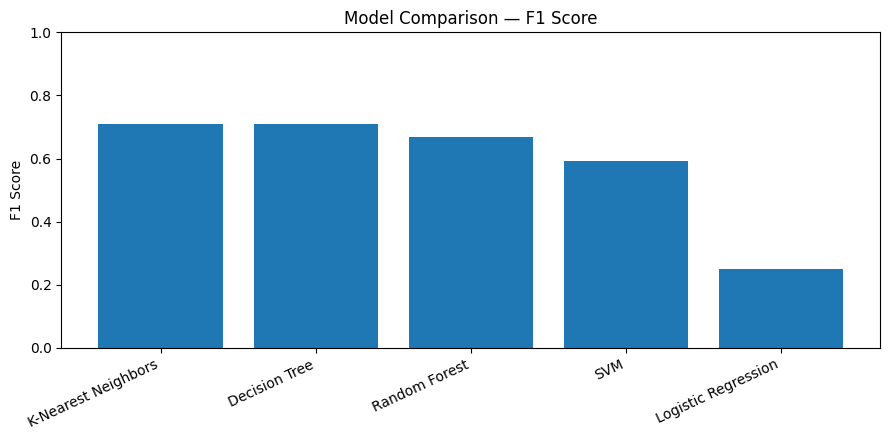

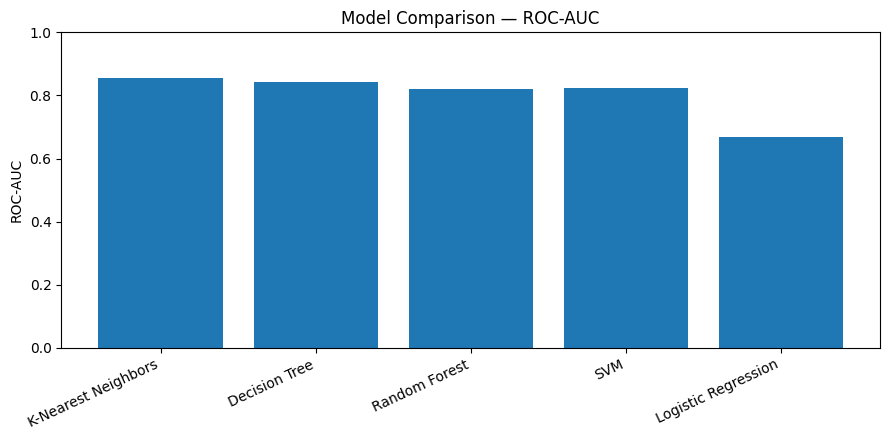

In [10]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(9, 4.5))
    plt.bar(results_df["Model"], results_df[metric])
    plt.ylim(0, 1)
    plt.ylabel(metric)
    plt.title(f"Model Comparison — {metric}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## 8. Cross-validation check

A 5-fold stratified cross-validation is used on the training data to see whether the ranking is reasonably stable and to avoid relying only on one train-test split.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    cv_rows.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

cv_df = pd.DataFrame(cv_rows).sort_values("Mean CV F1", ascending=False).reset_index(drop=True)
display(cv_df.round(4))

,Model,Mean CV F1,Std CV F1
0,K-Nearest Neighbors,0.8068,0.0174
1,Decision Tree,0.7859,0.1037
2,Random Forest,0.7434,0.0498
3,SVM,0.6873,0.0718
4,Logistic Regression,0.3814,0.0921


## 9. Overfitting and underfitting

A very shallow decision tree may **underfit** because it cannot capture enough structure. An unrestricted tree may **overfit** because it can memorize training examples. We compare training and test F1-score across tree depths.

In [12]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
depth_rows = []

for depth in depths:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE))
    ])
    pipe.fit(X_train, y_train)

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    depth_rows.append({
        "Max Depth": "None" if depth is None else depth,
        "Train F1": f1_score(y_train, train_pred, zero_division=0),
        "Test F1": f1_score(y_test, test_pred, zero_division=0)
    })

depth_df = pd.DataFrame(depth_rows)
display(depth_df.round(4))

,Max Depth,Train F1,Test F1
0,1,0.7042,0.6667
1,2,0.6593,0.5714
2,3,0.8673,0.7742
3,4,0.8972,0.7097
4,5,0.9278,0.6400
5,6,0.9434,0.6667
6,8,0.9714,0.6897
7,10,1.0000,0.6429
8,None,1.0000,0.6429


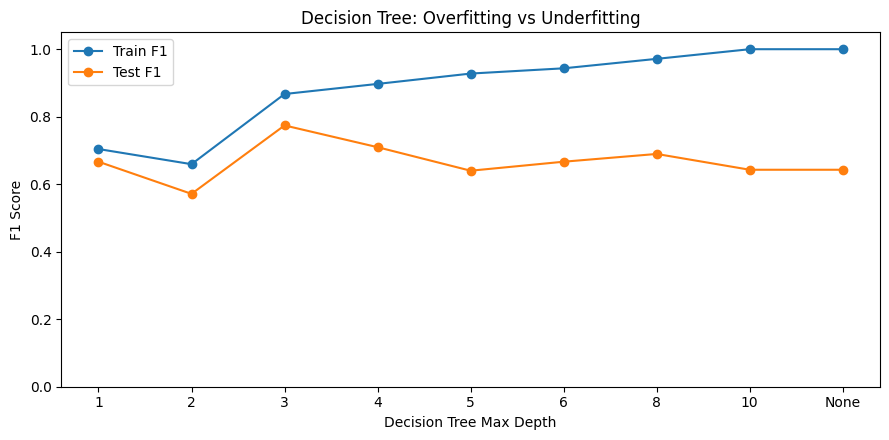

In [13]:
plot_depth = depth_df.copy()
plot_depth["Max Depth"] = plot_depth["Max Depth"].astype(str)

plt.figure(figsize=(9, 4.5))
plt.plot(plot_depth["Max Depth"], plot_depth["Train F1"], marker="o", label="Train F1")
plt.plot(plot_depth["Max Depth"], plot_depth["Test F1"], marker="o", label="Test F1")
plt.xlabel("Decision Tree Max Depth")
plt.ylabel("F1 Score")
plt.title("Decision Tree: Overfitting vs Underfitting")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Final conclusion

The best model is selected primarily using **F1-score**, with ROC-AUC as a secondary indicator because the classification classes are not perfectly balanced.

For this dataset and fixed train-test split, the **Decision Tree and KNN achieve the highest test F1-score**, while the Decision Tree is easier to interpret. Cross-validation should also be considered before deployment because the dataset is small (200 records), so a single split can be sensitive to sampling variation.

### Model strengths and weaknesses

| Model | Strengths | Weaknesses |
|---|---|---|
| Logistic Regression | Fast, simple, interpretable baseline | Limited nonlinear relationships; weakest result here |
| Decision Tree | Easy to explain; captures nonlinear rules | Can overfit without depth control |
| Random Forest | More robust than a single tree; captures nonlinear patterns | Less interpretable; can be heavier than a single tree |
| KNN | Simple; effective with scaled features | Sensitive to feature scaling and choice of K |
| SVM | Strong nonlinear decision boundaries | More computationally demanding and less interpretable |

### Key learning outcome

Model selection should not be based on accuracy alone. The appropriate metric depends on the problem: **precision** matters when false positives are costly, **recall** matters when missing positives is costly, and **F1-score** is useful when both precision and recall matter. ROC-AUC provides an additional threshold-independent view of discrimination.